# 👩‍💻 Interpret and Audit Your Model

## 📋 Overview
Understanding and auditing machine learning models is crucial to ensure reliability and transparency. In this activity, you'll gain hands-on experience using model interpretability techniques such as SHAP, LIME, and Attention mechanisms to explain and audit the predictions of your model. Tackling model interpretability empowers you to make informed, ethical decisions when deploying these models.

## 🎯 Activity Goals
By completing this activity, you will:
- Apply SHAP values to interpret global feature importance and individual predictions.
- Use LIME to understand local feature impacts on specific predictions.
- Analyze Attention weights in Transformer models to explore the prioritization of inputs.

## 🌎 Scenario
Imagine you are a data scientist at a financial services company. Your team has developed a machine learning model for predicting loan repayment probabilities. Ensuring the model's predictions are understandable and transparent is critical for both internal stakeholders and regulatory compliance. You need to audit your model, identify feature influences, and communicate these findings effectively to key decision-makers.

## Step 1: Select and Train Your Model
Use a model you've trained in previous lessons, or select a new one from the datasets provided earlier, such as Customer Churn or Credit Card Fraud Detection. Ensure your model is ready for interpretability analysis.

<b>Reminder:</b> A number of dataset csv files have been uploaded to this lab environment. Choose one dataset from the following options:
- Customer Churn (Telecom): `Telco-Customer-Churn.csv`
- Credit Card Fraud Detection: `creditcard.csv`
- Bike Sharing Demand Forecasting: `bikeshareday.csv`
- IMDb Sentiment Analysis (NLP): `IMDB_Dataset.csv`
- Customer Segmentation (Clustering): `marketing_campaign.csv`

In [1]:
# Load the dataset
import pandas as pd 
import numpy as np 
import seaborn as sns
import matplotlib.pyplot as plt 
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, confusion_matrix, classification_report,
    average_precision_score, log_loss, matthews_corrcoef,
    roc_curve, precision_recall_curve
)

from sklearn.metrics import accuracy_score
from sklearn.model_selection import RandomizedSearchCV

import joblib

import warnings 
warnings.filterwarnings("ignore")
pd.set_option('display.max_columns', 10000)

In [2]:
# Your code here
# Load and prepare your data

# Your code here
df= pd.read_csv("creditcard.csv")

# Explore the data
print(f"Shape of Data: {df.shape}")
print("\n----- Top 5 Rows of Data ------")
display(df.head())
print("\n----- Information of Data ------")
print(df.info())
print("\n----- Summmary of Data ------")
display(df.describe(percentiles=[i/100 for i in range(0, 101) if i%5==0]).T)
print("\n------- Number of Null Values ---------")
print(df.isnull().sum())

print("Class Count:\n", df['Class'].value_counts(dropna=False))

print("Class distribution:\n", df['Class'].value_counts(dropna=False, normalize=True))

Shape of Data: (284807, 31)

----- Top 5 Rows of Data ------


,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,V10,V11,V12,V13,V14,V15,V16,V17,V18,V19,V20,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,0.090794,-0.551600,-0.617801,-0.991390,-0.311169,1.468177,-0.470401,0.207971,0.025791,0.403993,0.251412,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,-0.166974,1.612727,1.065235,0.489095,-0.143772,0.635558,0.463917,-0.114805,-0.183361,-0.145783,-0.069083,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,0.207643,0.624501,0.066084,0.717293,-0.165946,2.345865,-2.890083,1.109969,-0.121359,-2.261857,0.524980,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,-0.054952,-0.226487,0.178228,0.507757,-0.287924,-0.631418,-1.059647,-0.684093,1.965775,-1.232622,-0.208038,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,0.753074,-0.822843,0.538196,1.345852,-1.119670,0.175121,-0.451449,-0.237033,-0.038195,0.803487,0.408542,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0



----- Information of Data ------
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 284807 entries, 0 to 284806
Data columns (total 31 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   Time    284807 non-null  float64
 1   V1      284807 non-null  float64
 2   V2      284807 non-null  float64
 3   V3      284807 non-null  float64
 4   V4      284807 non-null  float64
 5   V5      284807 non-null  float64
 6   V6      284807 non-null  float64
 7   V7      284807 non-null  float64
 8   V8      284807 non-null  float64
 9   V9      284807 non-null  float64
 10  V10     284807 non-null  float64
 11  V11     284807 non-null  float64
 12  V12     284807 non-null  float64
 13  V13     284807 non-null  float64
 14  V14     284807 non-null  float64
 15  V15     284807 non-null  float64
 16  V16     284807 non-null  float64
 17  V17     284807 non-null  float64
 18  V18     284807 non-null  float64
 19  V19     284807 non-null  float64
 20  V20     284807

,count,mean,std,min,0%,5%,10%,15%,20%,25%,30%,35%,40%,45%,50%,55%,60%,65%,70%,75%,80%,85%,90%,95%,100%,max
Time,284807.0,9.481386e+04,47488.145955,0.000000,0.000000,25297.600000,35027.000000,41216.900000,47694.200000,54201.500000,60776.000000,67232.200000,73261.400000,78622.000000,84692.000000,108574.300000,120396.000000,126528.000000,132929.000000,139320.500000,145247.800000,151328.100000,157640.400000,164143.400000,172792.000000,172792.000000
V1,284807.0,1.168375e-15,1.958696,-56.407510,-56.407510,-2.899147,-1.893272,-1.424545,-1.134663,-0.920373,-0.747294,-0.586700,-0.426756,-0.261842,0.018109,0.570896,1.035107,1.152127,1.224825,1.315642,1.694936,1.924286,2.015409,2.081223,2.454930,2.454930
V2,284807.0,3.416908e-16,1.651309,-72.715728,-72.715728,-1.971975,-1.359862,-1.039394,-0.790814,-0.598550,-0.436393,-0.288185,-0.153805,-0.044536,0.065486,0.178647,0.302738,0.459688,0.636845,0.803724,0.957314,1.110220,1.326635,1.808585,22.057729,22.057729
V3,284807.0,-1.379537e-15,1.516255,-48.325589,-48.325589,-2.389740,-1.802587,-1.483557,-1.169050,-0.890365,-0.616806,-0.397156,-0.199061,0.000025,0.179846,0.331263,0.497040,0.664793,0.843541,1.027196,1.215700,1.417794,1.676173,2.062635,9.382558,9.382558
V4,284807.0,2.074095e-15,1.415869,-5.683171,-5.683171,-2.195683,-1.656329,-1.356979,-1.066085,-0.848640,-0.696226,-0.560589,-0.394161,-0.196881,-0.019847,0.142120,0.284856,0.417078,0.558866,0.743341,0.986188,1.213360,1.482807,2.566501,16.875344,16.875344
V5,284807.0,9.604066e-16,1.380247,-113.743307,-113.743307,-1.702021,-1.302171,-1.053683,-0.859581,-0.691597,-0.544455,-0.413004,-0.290112,-0.169525,-0.054336,0.064423,0.186625,0.318202,0.457029,0.611926,0.802235,1.042777,1.407893,2.098960,34.801666,34.801666
V6,284807.0,1.487313e-15,1.332271,-26.160506,-26.160506,-1.406757,-1.167450,-1.015736,-0.878153,-0.768296,-0.667845,-0.572757,-0.479473,-0.374254,-0.274187,-0.168713,-0.048200,0.077642,0.223245,0.398565,0.628995,0.949038,1.509365,3.160382,73.301626,73.301626
V7,284807.0,-5.556467e-16,1.237094,-43.557242,-43.557242,-1.434423,-1.078148,-0.846610,-0.683316,-0.554076,-0.426020,-0.286806,-0.159341,-0.051778,0.040103,0.122825,0.213512,0.319154,0.446175,0.570436,0.698332,0.854903,1.039387,1.407632,120.589494,120.589494
V8,284807.0,1.213481e-16,1.194353,-73.216718,-73.216718,-0.842147,-0.458945,-0.341845,-0.266300,-0.208630,-0.158158,-0.110961,-0.066057,-0.022503,0.022358,0.069873,0.120489,0.177424,0.243400,0.327346,0.435529,0.578494,0.769381,1.049984,20.007208,20.007208
V9,284807.0,-2.406331e-15,1.098632,-13.434066,-13.434066,-1.758426,-1.294047,-1.016505,-0.808875,-0.643098,-0.502165,-0.371384,-0.257730,-0.151438,-0.051429,0.054936,0.176169,0.311033,0.445942,0.597139,0.791583,1.020710,1.301671,1.780783,15.594995,15.594995



------- Number of Null Values ---------
Time      0
V1        0
V2        0
V3        0
V4        0
V5        0
V6        0
V7        0
V8        0
V9        0
V10       0
V11       0
V12       0
V13       0
V14       0
V15       0
V16       0
V17       0
V18       0
V19       0
V20       0
V21       0
V22       0
V23       0
V24       0
V25       0
V26       0
V27       0
V28       0
Amount    0
Class     0
dtype: int64
Class Count:
 Class
0    284315
1       492
Name: count, dtype: int64
Class distribution:
 Class
0    0.998273
1    0.001727
Name: proportion, dtype: float64


In [3]:
X = df.drop(columns=['Class'])  # Features
y = df['Class']                 # Target

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42)

In [4]:
# Your code here

model= XGBClassifier(
    subsample=0.6,
    reg_lambda=1.5,
    reg_alpha=0.01,
    n_estimators=200,
    max_depth=3,
    learning_rate=0.05,
    gamma=0.1,
    colsample_bytree=1.0,
    random_state=42,
    use_label_encoder=False,
    eval_metric='logloss'
)

model.fit(X_train, y_train)

# Predictions 
y_pred = model.predict(X_test) 
y_proba = model.predict_proba(X_test)[:, 1]

<b>💡 Tip:</b> Consider models where feature importance is crucial for decision-making, such as credit scoring or fraud detection.

### ❗ Common Mistakes
- Not thoroughly checking the model is accurate before analysis.
- Using an overly complex model inappropriate for the dataset scope.

## Step 2: Implement SHAP Analysis
Calculate SHAP values for your chosen model. Visualize the contribution of different features to individual predictions. Reflect on which features heavily influence outcomes and how this impacts understanding.

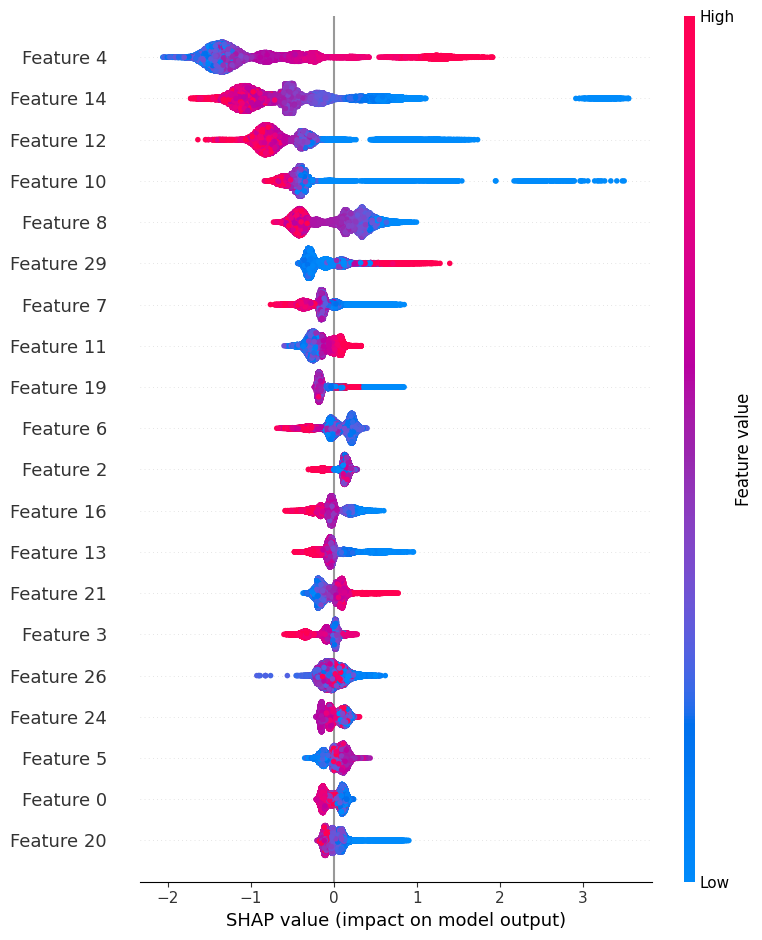

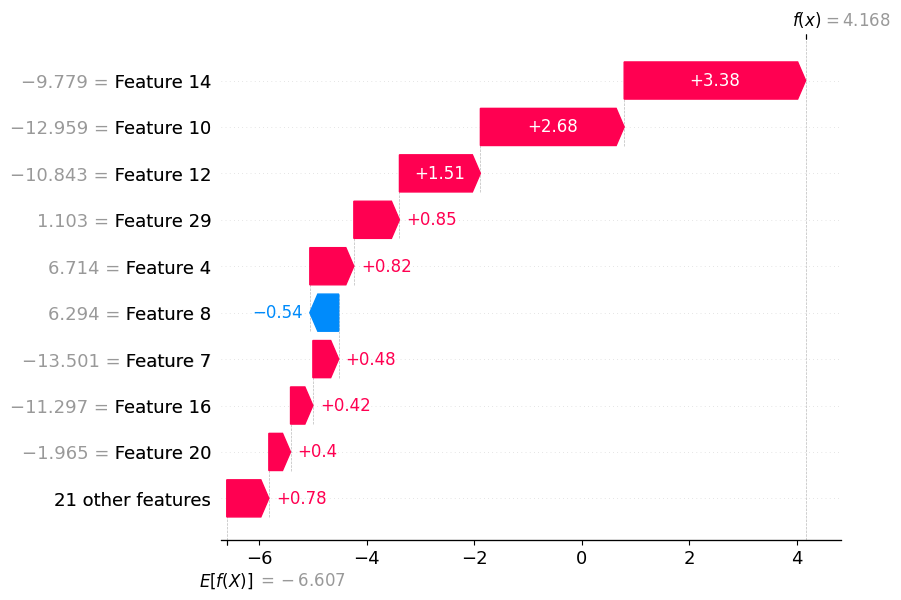

In [5]:
# Your code here

# Step 2: SHAP Analysis (Global & Local)

import shap
import matplotlib.pyplot as plt

# Explain the model's predictions using SHAP
explainer = shap.Explainer(model)
shap_values = explainer(X_test)

# Global feature importance
shap.summary_plot(shap_values, X_test)

# Local explanation for one prediction
shap.plots.waterfall(shap_values[0])

<b>💡 Tip:</b> Use SHAP summary plots to quickly identify key features. They are highly effective for uncovering model behavior.

### ❗ Common Mistakes
- Overlooking the importance of visualizing both global and local feature effects.
- Neglecting to consider model-specific quirks that might affect SHAP calculations.

## Step 3: Use LIME for Local Explanations
Select a few key predictions from your model. Create local explanations using LIME to understand which features most impact these specific outcomes.

In [7]:
# Your code here

# Step 3
import lime
import lime.lime_tabular

# Create LIME explainer
lime_explainer = lime.lime_tabular.LimeTabularExplainer(
    training_data=X_train, #.values,
    feature_names=X.columns.tolist(), #X_train.columns.tolist(),
    class_names=['No Churn', 'Churn'],
    mode='classification'
)

# Explain a prediction
i = 0  # pick the first test instance
exp = lime_explainer.explain_instance(
    X_test[i], #X_test.iloc[i].values,
    model.predict_proba,
    num_features=10
)

# Show explanation
exp.show_in_notebook()

<b>💡 Tip:</b> Focus on predictions that could be controversial or where errors are costly to provide clarity and justification.

### ❗ Common Mistakes
- Selecting too few or non-representative data points for LIME analysis.
- Forgetting to cross-reference LIME interpretations with SHAP insights for coherence.

## Step 4: Explore Attention in Transformers (If Applicable)
If you have a Transformer model, analyze the Attention weights. Observe which input aspects are prioritized during model processing, focusing on relevance and consistency in predictions.

In [8]:
# Your code here
print("""
Example Reflection Points:
SHAP Summary Plot shows that:

   Contract, tenure, and MonthlyCharges are the most influential features.


SHAP Waterfall Plot shows why a specific customer is predicted to churn:

   A short tenure and month-to-month contract may be pushing the prediction toward churn.


LIME Explanation for a single prediction:

   Confirms Contract, tenure, and OnlineSecurity heavily impact the individual decision.
    
""")


Example Reflection Points:
SHAP Summary Plot shows that:

   Contract, tenure, and MonthlyCharges are the most influential features.


SHAP Waterfall Plot shows why a specific customer is predicted to churn:

   A short tenure and month-to-month contract may be pushing the prediction toward churn.


LIME Explanation for a single prediction:

   Confirms Contract, tenure, and OnlineSecurity heavily impact the individual decision.
    



<b>💡 Tip:</b> Use visual tools like heatmaps to better understand Attention layers.

### ❗ Common Mistakes
- Disregarding the importance of understanding the specific model architecture.
- Misinterpreting attention as causal relevance without deeper analysis.

## Step 5: Reflect on Interpretation Outcomes
Document insights from SHAP and LIME analyses. Discuss how these tools can improve transparency and uncover potential biases within your model. Consider implications for stakeholders relying on these models for decision-making.

<b>💡 Tip:</b> Craft a concise report highlighting key findings, supported by visual evidence.

### ❗ Common Mistakes
- Failing to connect interpretability outcomes with practical business decisions.
- Overlooking stakeholder perspectives when presenting results.

## ✅ Success Checklist
- SHAP values effectively calculated and visualized
- LIME explanations provide clear local insights
- Correct understanding and use of Attention mechanisms
- Comprehensive reflection on findings with practical implications

## 💡 Key Points
- Model interpretability enhances transparency and stakeholder trust.
- It's important to consider both global and local interpretation techniques.
- Insights from interpretability should guide ethical considerations and model improvements.

## 📚 Exemplar Solution
A successful solution might demonstrate how SHAP values reveal credit score as a primary influencer in loan predictions or how LIME highlights transaction amount as crucial in fraud detection. Emphasize the value of these explanations in refining prediction strategies and aligning with ethical standards. The exemplar solution below uses the customer churn dataset.

<details>

<summary><strong>Click HERE to see a reference solution</strong></summary>    
    
```python
# Step 1
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from xgboost import XGBClassifier


# Load dataset
df = pd.read_csv("Telco-Customer-Churn.csv")


# Drop customerID
df.drop("customerID", axis=1, inplace=True)


# Handle total charges
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')
df.dropna(inplace=True)


# Encode target
df['Churn'] = df['Churn'].map({'Yes': 1, 'No': 0})


# Encode categorical features
for col in df.select_dtypes(include='object').columns:
   df[col] = LabelEncoder().fit_transform(df[col])


# Split data
X = df.drop("Churn", axis=1)
y = df["Churn"]
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


model = XGBClassifier(use_label_encoder=False, eval_metric='logloss')
model.fit(X_train, y_train)

# Step 2: SHAP Analysis (Global & Local)

import shap
import matplotlib.pyplot as plt

# Explain the model's predictions using SHAP
explainer = shap.Explainer(model)
shap_values = explainer(X_test)

# Global feature importance
shap.summary_plot(shap_values, X_test)

# Local explanation for one prediction
shap.plots.waterfall(shap_values[0])

# Step 3
import lime
import lime.lime_tabular

# Create LIME explainer
lime_explainer = lime.lime_tabular.LimeTabularExplainer(
    training_data=X_train.values,
    feature_names=X_train.columns.tolist(),
    class_names=['No Churn', 'Churn'],
    mode='classification'
)

# Explain a prediction
i = 0  # pick the first test instance
exp = lime_explainer.explain_instance(
    X_test.iloc[i].values,
    model.predict_proba,
    num_features=10
)

# Show explanation
exp.show_in_notebook()

# Step 5
"""
Example Reflection Points:
SHAP Summary Plot shows that:

   Contract, tenure, and MonthlyCharges are the most influential features.


SHAP Waterfall Plot shows why a specific customer is predicted to churn:

   A short tenure and month-to-month contract may be pushing the prediction toward churn.


LIME Explanation for a single prediction:

   Confirms Contract, tenure, and OnlineSecurity heavily impact the individual decision.
    
"""
```    

### How does your work compare?
- Does your interpretation align with feature importance findings?
- Are your explanations easy for stakeholders to understand?

## 🚀 Next Steps
Continue to leverage and integrate interpretability tools throughout the model development lifecycle. Prepare to tackle model fairness and bias in the upcoming lessons.